## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

2026-05-25 09:31:33.396563: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 09:31:33.428045: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 09:31:34.148767: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All libraries imported successfully!


## Load data

In [2]:
print("Loading creditcard.csv dataset...")
df = pd.read_csv('../Dataset/creditcard.csv') 

print(f"\nDataset shape: {df.shape}")

print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nClass distribution (0: Normal, 1: Fraud):")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Loading creditcard.csv dataset...

Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009

## Prepare features and target

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 30)
Target shape: (284807,)


### Building models

In [4]:
class KerasClassifierWrapper:
    def __init__(self, model_fn, epochs=50, batch_size=32, verbose=0):
        self.model_fn = model_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
    
    def fit(self, X, y):
        self.model = self.model_fn()
        
        # Add early stopping
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
        
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, 
                       verbose=self.verbose, validation_split=0.1,
                       callbacks=[early_stop])  # Add callbacks parameter
        return self
    
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    
    def predict_proba(self, X):
        """Return probability of class 1 (fraud)"""
        probs = self.model.predict(X, verbose=0)
        if len(probs.shape) == 2:
            if probs.shape[1] == 2:
                return probs[:, 1]
            else:
                return probs.flatten()
        else:
            return probs.flatten()

    
def clear_keras_session():
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

    
def get_pred_proba(clf, X):
    """Safely get prediction probabilities from any classifier"""
    if not hasattr(clf, "predict_proba"):
        return None
    
    try:
        y_pred_proba = clf.predict_proba(X)
        
        # Handle different output shapes
        if hasattr(y_pred_proba, 'numpy'):
            y_pred_proba = y_pred_proba.numpy()
        
        if len(y_pred_proba.shape) == 2:
            if y_pred_proba.shape[1] == 2:
                return y_pred_proba[:, 1]  # Binary classification
            else:
                return y_pred_proba.flatten()  # Multi-class or unusual shape
        else:
            return y_pred_proba.flatten()  # Already 1D
    except Exception as e:
        print(f"Warning: Could not get probabilities: {e}")
        return None

# Define neural network architectures
def create_nn_model():
    """Simple Feed-Forward Neural Network"""
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_cnn_model():
    """1D Convolutional Neural Network"""
    model = models.Sequential([
        layers.Reshape((X.shape[1], 1), input_shape=(X.shape[1],)),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_autoencoder_model():
    """Autoencoder for anomaly detection (pretrain then fine-tune)"""
    input_dim = X.shape[1]
    
    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(64, activation='relu')(input_layer)
    encoded = layers.Dropout(0.3)(encoded)
    encoded = layers.Dense(32, activation='relu')(encoded)
    encoded = layers.Dense(16, activation='relu')(encoded)
    
    # Decoder
    decoded = layers.Dense(32, activation='relu')(encoded)
    decoded = layers.Dense(64, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)
    
    # Autoencoder
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # For classification, add a classification head
    classification_head = layers.Dense(1, activation='sigmoid')(encoded)
    classifier = models.Model(input_layer, classification_head)
    classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return classifier


### Define Evaluation Function

In [5]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name=""):
    """Calculate precision, recall, f1, and AUC for model evaluation"""
    # Ensure predictions are in correct format
    if hasattr(y_pred, 'numpy'):
        y_pred = y_pred.numpy()
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    if y_pred_proba is not None:
        if hasattr(y_pred_proba, 'numpy'):
            y_pred_proba = y_pred_proba.numpy()
        # Handle both 1D and 2D probability arrays
        if len(y_pred_proba.shape) > 1:
            y_pred_proba = y_pred_proba[:, 1] if y_pred_proba.shape[1] == 2 else y_pred_proba.flatten()
        auc = roc_auc_score(y_true, y_pred_proba)
        metrics['AUC-ROC'] = auc
    
    return metrics

def print_metrics(metrics, model_name=""):
    """Pretty print metrics"""
    if model_name:
        print(f"\n📊 {model_name}:")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    if 'AUC-ROC' in metrics:
        print(f"  AUC-ROC:   {metrics['AUC-ROC']:.4f}")

## Demonstrate DIFFERENT types of data leakage

### LEAKAGE 1 - Scaling before splitting (using full dataset statistics)

In [6]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 1: Scaling before train-test split")
print("="*80)

# Define classifiers
classifiers = {
    # Traditional ML Classifiers
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=50, max_depth=3),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=50, max_depth=3, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=50, max_depth=3, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, iterations=50, depth=3, verbose=0),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=50),
    'MLP (Sklearn)': MLPClassifier(random_state=42, hidden_layer_sizes=(100, 50), max_iter=200),
    
    # Deep Learning Models (wrapped for sklearn compatibility)
    'Neural Network (Keras)': KerasClassifierWrapper(create_nn_model, epochs=30),
    'CNN 1D': KerasClassifierWrapper(create_cnn_model, epochs=30),
    'Autoencoder': KerasClassifierWrapper(create_autoencoder_model, epochs=30)
}

# Leaky approach: Scale the entire dataset before splitting
scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X)
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_scaled_leaky, y, test_size=0.3, random_state=42, stratify=y
)

# Correct approach: Scale after splitting
X_train_correct, X_test_correct, y_train_correct, y_test_correct = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler_correct = StandardScaler()
X_train_correct_scaled = scaler_correct.fit_transform(X_train_correct)
X_test_correct_scaled = scaler_correct.transform(X_test_correct)

# Store results
results_leaky_scaling = {name: {} for name in classifiers.keys()}
results_correct_scaling = {name: {} for name in classifiers.keys()}

# Train and evaluate with leaky scaling
print("\n❌ With LEAKY scaling (using full dataset statistics):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_leaky, y_train_leaky)
    y_pred = clf.predict(X_test_leaky)
    y_pred_proba = get_pred_proba(clf, X_test_leaky)
    
    metrics = evaluate_model(y_test_leaky, y_pred, y_pred_proba)
    results_leaky_scaling[name] = metrics
    print_metrics(metrics, name)

# Train and evaluate with correct scaling
print("\n✅ With CORRECT scaling (fit on train only):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_correct_scaled, y_train_correct)
    y_pred = clf.predict(X_test_correct_scaled)
    y_pred_proba = get_pred_proba(clf, X_test_correct_scaled)
    
    metrics = evaluate_model(y_test_correct, y_pred, y_pred_proba)
    results_correct_scaling[name] = metrics
    print_metrics(metrics, name)


🔴 LEAKAGE TYPE 1: Scaling before train-test split

❌ With LEAKY scaling (using full dataset statistics):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8476
  Recall:    0.6014
  F1-Score:  0.7036
  AUC-ROC:   0.9575

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557

📊 Gradient Boosting:
  Precision: 0.7273
  Recall:    0.1622
  F1-Score:  0.2652
  AUC-ROC:   0.3446

📊 XGBoost:
  Precision: 0.8370
  Recall:    0.7635
  F1-Score:  0.7986
  AUC-ROC:   0.9185

📊 LightGBM:
  Precision: 0.3057
  Recall:    0.5473
  F1-Score:  0.3923
  AUC-ROC:   0.6554

📊 CatBoost:
  Precision: 0.9145
  Recall:    0.7230
  F1-Score:  0.8075
  AUC-ROC:   0.9544

📊 AdaBoost:
  Precision: 0.7353
  Recall:    0.6757
  F1-Score:  0.7042
  AUC-ROC:   0.9675

📊 MLP (Sklearn):
  Precision: 0.8889
  Recall:    0.7568
  

2026-05-25 09:33:53.346373: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



📊 Neural Network (Keras):
  Precision: 0.8162
  Recall:    0.7500
  F1-Score:  0.7817
  AUC-ROC:   0.9557

📊 CNN 1D:
  Precision: 0.8397
  Recall:    0.7432
  F1-Score:  0.7885
  AUC-ROC:   0.9698

📊 Autoencoder:
  Precision: 0.8156
  Recall:    0.7770
  F1-Score:  0.7958
  AUC-ROC:   0.9632

✅ With CORRECT scaling (fit on train only):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8505
  Recall:    0.6149
  F1-Score:  0.7137
  AUC-ROC:   0.9567

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557

📊 Gradient Boosting:
  Precision: 0.7273
  Recall:    0.1622
  F1-Score:  0.2652
  AUC-ROC:   0.3446

📊 XGBoost:
  Precision: 0.8370
  Recall:    0.7635
  F1-Score:  0.7986
  AUC-ROC:   0.9185

📊 LightGBM:
  Precision: 0.4348
  Recall:    0.2027
  F1-Score:  0.2765
  AUC-ROC:   0.3306

📊 CatBoost:


#### Visualize scaling leakage impact

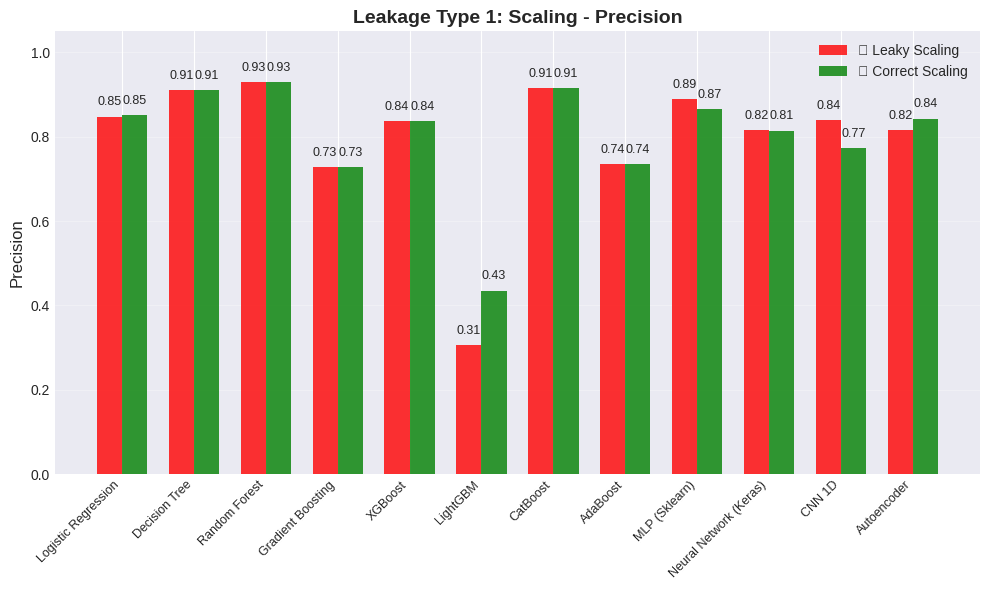

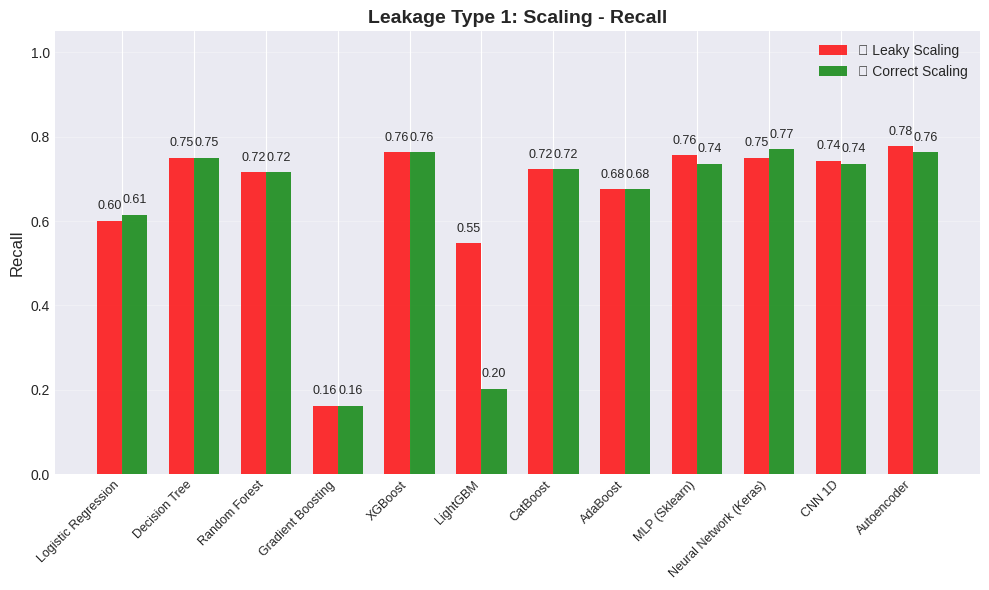

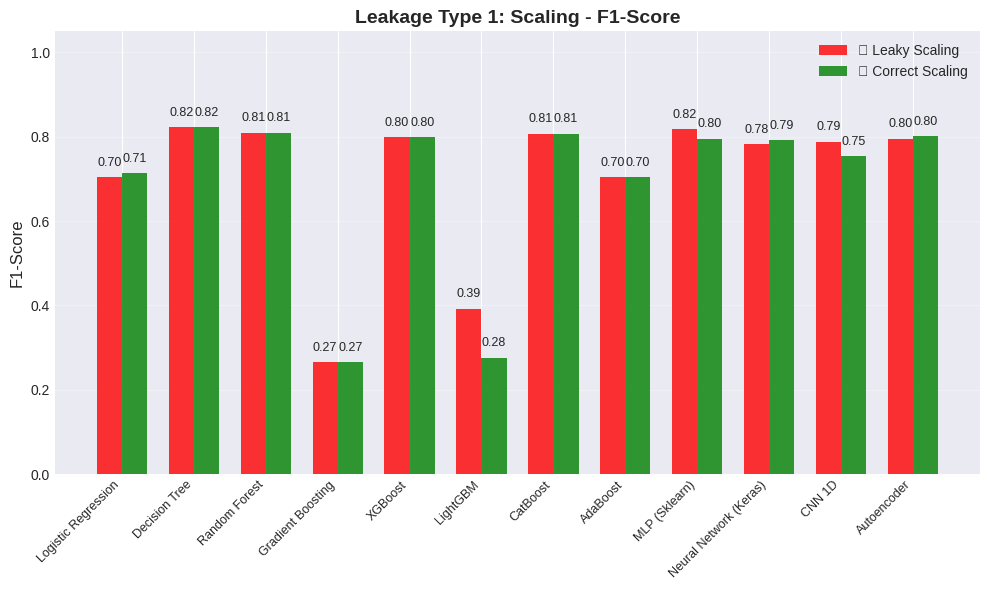

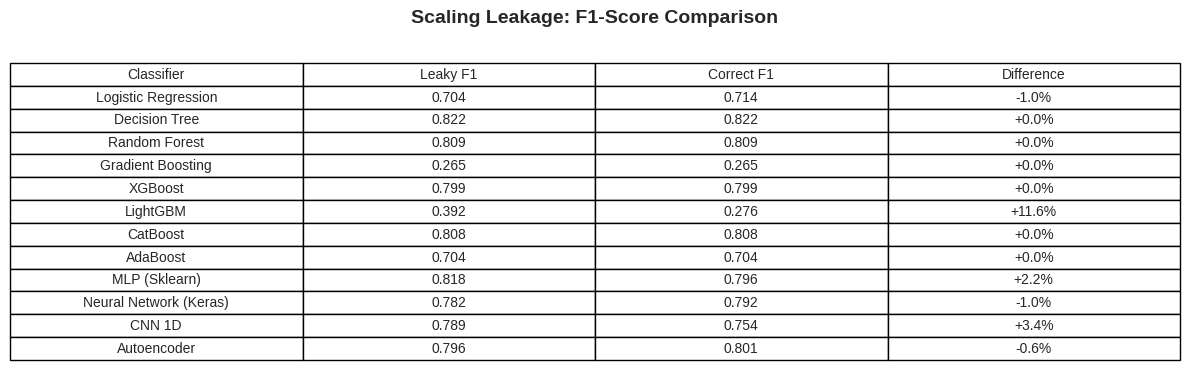

In [7]:
# Individual graphs for Scaling Leakage
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_pos = np.arange(len(classifiers))
    width = 0.35
    
    leaky_scores = [results_leaky_scaling[name][metric] for name in classifiers.keys()]
    correct_scores = [results_correct_scaling[name][metric] for name in classifiers.keys()]
    
    bars1 = ax.bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky Scaling', alpha=0.8, color='red')
    bars2 = ax.bar(x_pos + width/2, correct_scores, width, label='✅ Correct Scaling', alpha=0.8, color='green')
    
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Leakage Type 1: Scaling - {metric}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(classifiers.keys(), rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Separate table for Scaling Leakage
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = []
for name in classifiers.keys():
    table_data.append([
        name,
        f"{results_leaky_scaling[name]['F1-Score']:.3f}",
        f"{results_correct_scaling[name]['F1-Score']:.3f}",
        f"{(results_leaky_scaling[name]['F1-Score'] - results_correct_scaling[name]['F1-Score'])*100:+.1f}%"
    ])

table = ax.table(cellText=table_data,
                 colLabels=['Classifier', 'Leaky F1', 'Correct F1', 'Difference'],
                 loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax.set_title('Scaling Leakage: F1-Score Comparison', fontsize=14, fontweight='bold', pad=60)
plt.tight_layout()
plt.show()

clear_keras_session()

### LEAKAGE 2 - CROSS-VALIDATION LEAKAGE

In [8]:
# Create CV-specific classifiers (without deep learning models)
classifiers_cv = {name: clf for name, clf in classifiers.items() 
                  if not any(x in name for x in ['CNN', 'Autoencoder','Neural Network (Keras)'])}

In [9]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 2: Preprocessing before Cross-Validation")
print("="*80)

# Leaky CV approach: Preprocess entire dataset before CV
print("\n❌ LEAKY Cross-Validation (preprocessing all data first):")
print("-" * 60)

cv_results_leaky = {name: {'Precision': [], 'Recall': [], 'F1-Score': []} for name in classifiers.keys()}

X_scaled_full = StandardScaler().fit_transform(X)

for name, clf in classifiers_cv.items():
    # Use cross_validate to get multiple metrics
    scores = cross_validate(clf, X_scaled_full, y, cv=5, 
                           scoring=['precision', 'recall', 'f1'])
    
    cv_results_leaky[name]['Precision'] = scores['test_precision'].mean()
    cv_results_leaky[name]['Recall'] = scores['test_recall'].mean()
    cv_results_leaky[name]['F1-Score'] = scores['test_f1'].mean()
    
    print(f"\n{name}:")
    print(f"  Precision: {cv_results_leaky[name]['Precision']:.4f} (+/- {scores['test_precision'].std() * 2:.4f})")
    print(f"  Recall:    {cv_results_leaky[name]['Recall']:.4f} (+/- {scores['test_recall'].std() * 2:.4f})")
    print(f"  F1-Score:  {cv_results_leaky[name]['F1-Score']:.4f} (+/- {scores['test_f1'].std() * 2:.4f})")

# Correct CV approach: Use pipeline to prevent leakage
print("\n✅ CORRECT Cross-Validation (preprocessing inside CV folds):")
print("-" * 60)

cv_results_correct = {name: {'Precision': [], 'Recall': [], 'F1-Score': []} for name in classifiers_cv.keys()}

for name, clf in classifiers_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    
    scores = cross_validate(pipeline, X, y, cv=5,
                           scoring=['precision', 'recall', 'f1'])
    
    cv_results_correct[name]['Precision'] = scores['test_precision'].mean()
    cv_results_correct[name]['Recall'] = scores['test_recall'].mean()
    cv_results_correct[name]['F1-Score'] = scores['test_f1'].mean()
    
    print(f"\n{name}:")
    print(f"  Precision: {cv_results_correct[name]['Precision']:.4f} (+/- {scores['test_precision'].std() * 2:.4f})")
    print(f"  Recall:    {cv_results_correct[name]['Recall']:.4f} (+/- {scores['test_recall'].std() * 2:.4f})")
    print(f"  F1-Score:  {cv_results_correct[name]['F1-Score']:.4f} (+/- {scores['test_f1'].std() * 2:.4f})")


🔴 LEAKAGE TYPE 2: Preprocessing before Cross-Validation

❌ LEAKY Cross-Validation (preprocessing all data first):
------------------------------------------------------------

Logistic Regression:
  Precision: 0.8835 (+/- 0.1807)
  Recall:    0.6174 (+/- 0.3067)
  F1-Score:  0.7076 (+/- 0.1669)

Decision Tree:
  Precision: 0.7336 (+/- 0.7421)
  Recall:    0.7619 (+/- 0.1742)
  F1-Score:  0.6443 (+/- 0.6428)

Random Forest:
  Precision: 0.7614 (+/- 0.7720)
  Recall:    0.7495 (+/- 0.2920)
  F1-Score:  0.6363 (+/- 0.6453)

Gradient Boosting:
  Precision: 0.6650 (+/- 0.6851)
  Recall:    0.5329 (+/- 0.2698)
  F1-Score:  0.5531 (+/- 0.5550)

XGBoost:
  Precision: 0.5869 (+/- 0.6389)
  Recall:    0.5845 (+/- 0.6027)
  F1-Score:  0.5734 (+/- 0.5816)

LightGBM:
  Precision: 0.2219 (+/- 0.4517)
  Recall:    0.4628 (+/- 0.5304)
  F1-Score:  0.2576 (+/- 0.4545)

CatBoost:
  Precision: 0.7925 (+/- 0.5099)
  Recall:    0.7903 (+/- 0.1779)
  F1-Score:  0.7528 (+/- 0.3166)

AdaBoost:
  Precision: 0

#### Visualize Cross-Validation Leakage Impact

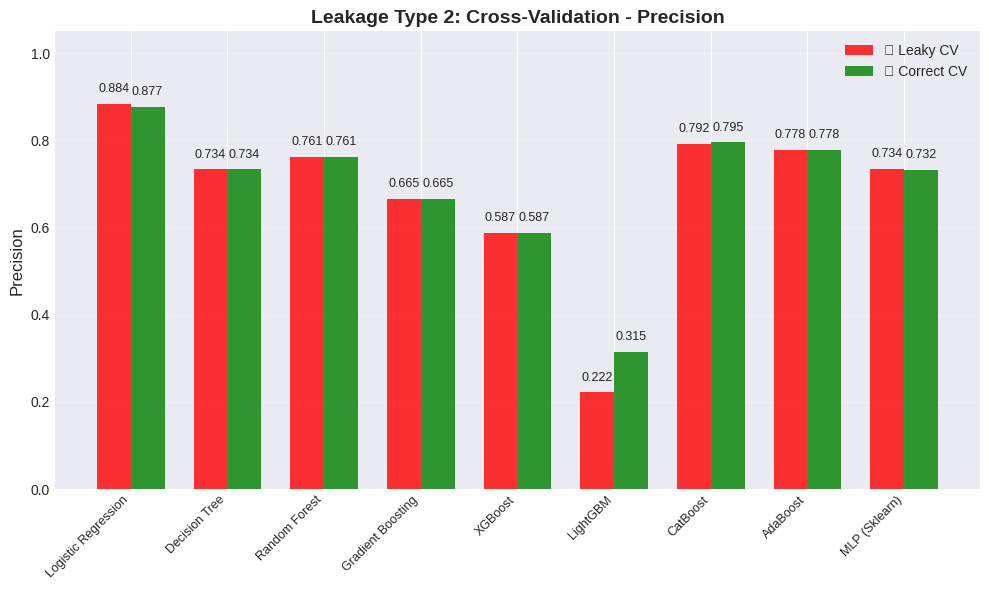

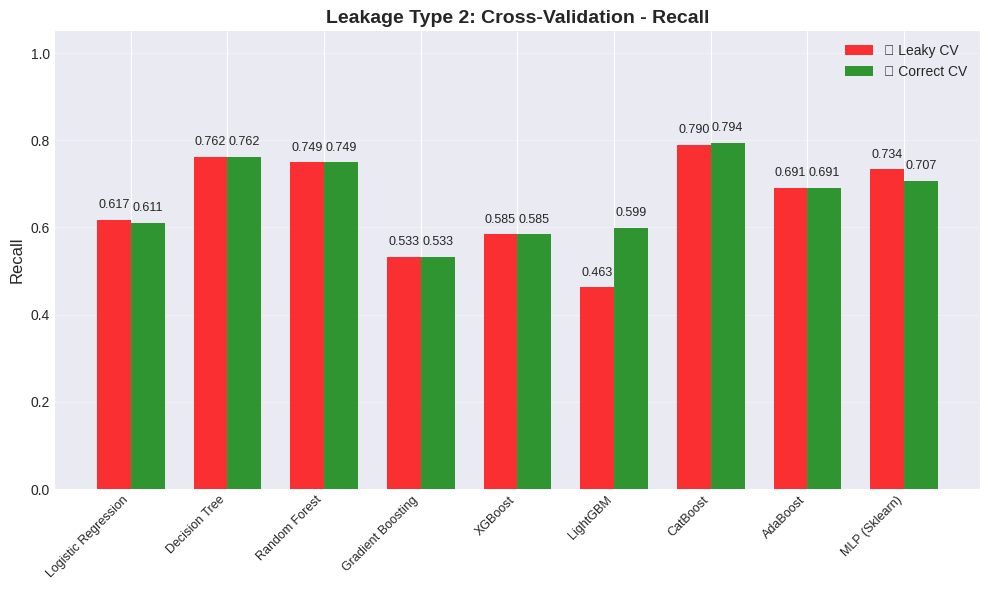

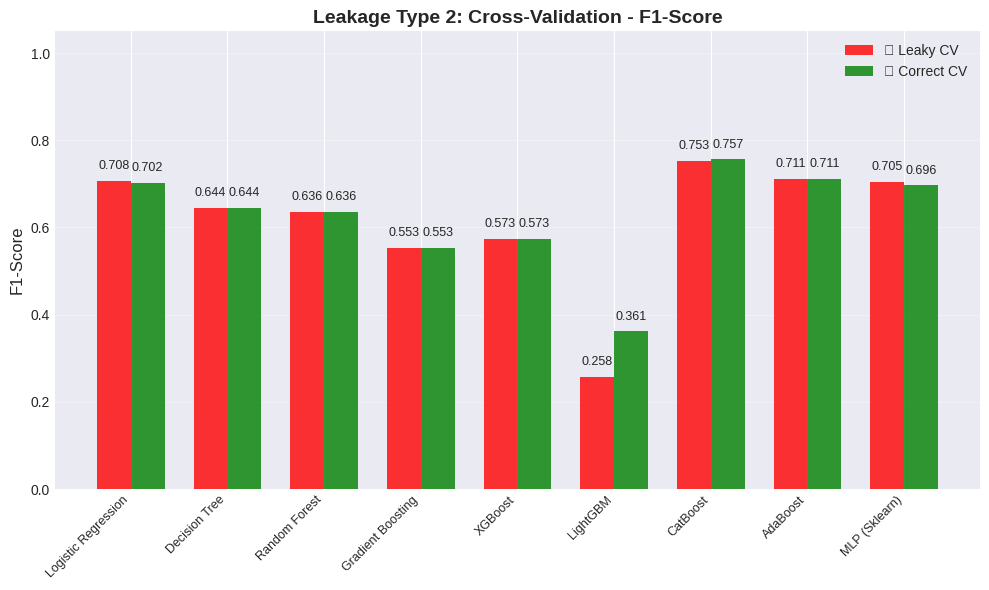

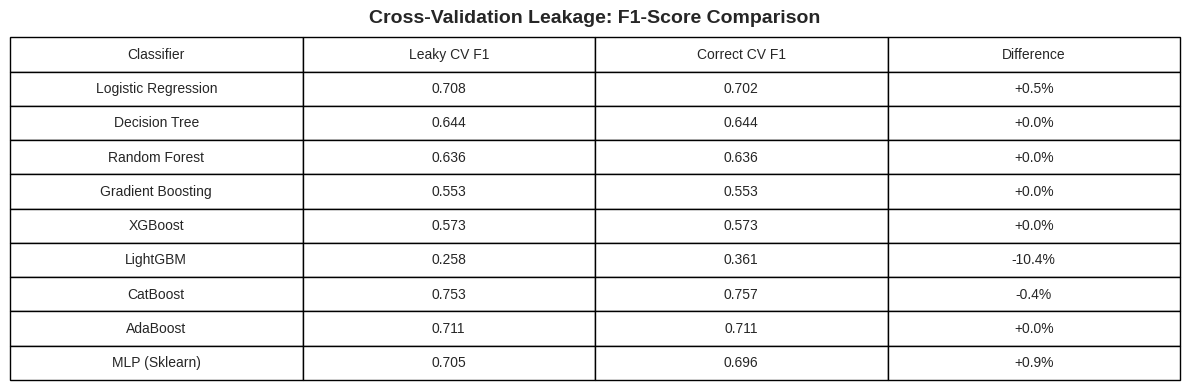

In [10]:
# Individual graphs for CV Leakage
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_pos = np.arange(len(classifiers_cv))
    width = 0.35
    
    leaky_scores = [cv_results_leaky[name][metric] for name in classifiers_cv.keys()]
    correct_scores = [cv_results_correct[name][metric] for name in classifiers_cv.keys()]
    
    bars1 = ax.bar(x_pos - width/2, leaky_scores, width, label='❌ Leaky CV', alpha=0.8, color='red')
    bars2 = ax.bar(x_pos + width/2, correct_scores, width, label='✅ Correct CV', alpha=0.8, color='green')
    
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Leakage Type 2: Cross-Validation - {metric}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(classifiers_cv.keys(), rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.05])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Separate table for CV Leakage
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = []
for name in classifiers_cv.keys():
    table_data.append([
        name,
        f"{cv_results_leaky[name]['F1-Score']:.3f}",
        f"{cv_results_correct[name]['F1-Score']:.3f}",
        f"{(cv_results_leaky[name]['F1-Score'] - cv_results_correct[name]['F1-Score'])*100:+.1f}%"
    ])

table = ax.table(cellText=table_data,
                 colLabels=['Classifier', 'Leaky CV F1', 'Correct CV F1', 'Difference'],
                 loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax.set_title('Cross-Validation Leakage: F1-Score Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

clear_keras_session()

#### LEAKAGE 4 - SAMPLING LEAKAGE (RUS & SMOTE)

##### Split data for sampling experiments (clean split first!)

In [11]:
print("\n" + "="*80)
print("🔴 LEAKAGE TYPE 3: Sampling Leakage (RandomUnderSampler & SMOTE)")
print("="*80)

# IMPORTANT: Split FIRST before any sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Data split correctly first!")
print(f"Training set shape: {X_train.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")
print(f"Test set shape: {X_test.shape}")
print(f"Test class distribution:\n{y_test.value_counts()}")

# Scale the data (correctly - fit on train only)
scaler_sampling = StandardScaler()
X_train_scaled = scaler_sampling.fit_transform(X_train)
X_test_scaled = scaler_sampling.transform(X_test)


🔴 LEAKAGE TYPE 3: Sampling Leakage (RandomUnderSampler & SMOTE)
✅ Data split correctly first!
Training set shape: (199364, 30)
Training class distribution:
Class
0    199020
1       344
Name: count, dtype: int64
Test set shape: (85443, 30)
Test class distribution:
Class
0    85295
1      148
Name: count, dtype: int64


###### LEAKY SAMPLING - Apply sampling BEFORE train-test split

In [12]:
print("\n" + "="*50)
print("❌ LEAKY SAMPLING: Applying sampling on FULL dataset before split")
print("="*50)

# Leaky Random Under Sampling
rus_leaky_full = RandomUnderSampler(random_state=42)
X_rus_sampled, y_rus_sampled = rus_leaky_full.fit_resample(X, y)

# Leaky SMOTE
smote_leaky_full = SMOTE(random_state=42)
X_smote_sampled, y_smote_sampled = smote_leaky_full.fit_resample(X, y)

# Now split the already-sampled data (THIS IS LEAKY!)
X_train_rus_leaky, X_test_rus_leaky, y_train_rus_leaky, y_test_rus_leaky = train_test_split(
    X_rus_sampled, y_rus_sampled, test_size=0.3, random_state=42, stratify=y_rus_sampled
)

X_train_smote_leaky, X_test_smote_leaky, y_train_smote_leaky, y_test_smote_leaky = train_test_split(
    X_smote_sampled, y_smote_sampled, test_size=0.3, random_state=42, stratify=y_smote_sampled
)

# Scale (additional leakage!)
scaler_rus_leaky = StandardScaler()
X_train_rus_leaky = scaler_rus_leaky.fit_transform(X_train_rus_leaky)
X_test_rus_leaky = scaler_rus_leaky.transform(X_test_rus_leaky)

scaler_smote_leaky = StandardScaler()
X_train_smote_leaky = scaler_smote_leaky.fit_transform(X_train_smote_leaky)
X_test_smote_leaky = scaler_smote_leaky.transform(X_test_smote_leaky)

# Train and evaluate leaky RUS
results_rus_leaky = {}
print("\n📊 Results with LEAKY Random Under Sampling:")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_rus_leaky, y_train_rus_leaky)
        y_pred = clf.predict(X_test_rus_leaky)
        y_pred_proba = get_pred_proba(clf, X_test_rus_leaky)
        
        metrics = evaluate_model(y_test_rus_leaky, y_pred, y_pred_proba)
        results_rus_leaky[name] = metrics
        print_metrics(metrics, name)

# Train and evaluate leaky SMOTE
results_smote_leaky = {}
print("\n📊 Results with LEAKY SMOTE:")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_smote_leaky, y_train_smote_leaky)
        y_pred = clf.predict(X_test_smote_leaky)
        y_pred_proba = get_pred_proba(clf, X_test_smote_leaky)
        
        metrics = evaluate_model(y_test_smote_leaky, y_pred, y_pred_proba)
        results_smote_leaky[name] = metrics
        print_metrics(metrics, name)


❌ LEAKY SAMPLING: Applying sampling on FULL dataset before split

📊 Results with LEAKY Random Under Sampling:
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.9855
  Recall:    0.9189
  F1-Score:  0.9510
  AUC-ROC:   0.9795

📊 Decision Tree:
  Precision: 0.9429
  Recall:    0.8919
  F1-Score:  0.9167
  AUC-ROC:   0.9331

📊 Random Forest:
  Precision: 0.9926
  Recall:    0.9054
  F1-Score:  0.9470
  AUC-ROC:   0.9846

📊 Gradient Boosting:
  Precision: 0.9580
  Recall:    0.9257
  F1-Score:  0.9416
  AUC-ROC:   0.9833

📊 XGBoost:
  Precision: 0.9507
  Recall:    0.9122
  F1-Score:  0.9310
  AUC-ROC:   0.9833

📊 LightGBM:
  Precision: 0.9574
  Recall:    0.9122
  F1-Score:  0.9343
  AUC-ROC:   0.9856

📊 CatBoost:
  Precision: 0.9574
  Recall:    0.9122
  F1-Score:  0.9343
  AUC-ROC:   0.9832

📊 AdaBoost:
  Precision: 0.9247
  Recall:    0.9122
  F1-Score:  0.9184
  AUC-ROC:   0.9761

📊 MLP (Sklearn):
  Precision: 0.9338
  Recall:    0.95

##### Demonstrate Correct Sampling (Only on Training Data)

In [13]:
print("\n" + "="*50)
print("✅ CORRECT SAMPLING: Applying sampling ONLY on training data")
print("="*50)

# Baseline (no sampling, just scaled data)
results_baseline = {}
print("\n📊 BASELINE (No sampling, just scaling):")
print("-" * 60)
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_pred_proba = get_pred_proba(clf, X_test_scaled)
    
    metrics = evaluate_model(y_test, y_pred, y_pred_proba)
    results_baseline[name] = metrics
    print_metrics(metrics, name)

# Correct Random Under Sampling (on training data only)
rus_correct = RandomUnderSampler(random_state=42)
X_train_rus_correct, y_train_rus_correct = rus_correct.fit_resample(X_train_scaled, y_train)

results_rus_correct = {}
print("\n📊 CORRECT Random Under Sampling (on training data only):")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_rus_correct, y_train_rus_correct)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = get_pred_proba(clf, X_test_scaled)
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        results_rus_correct[name] = metrics
        print_metrics(metrics, name)

# Correct SMOTE (on training data only)
smote_correct = SMOTE(random_state=42)
X_train_smote_correct, y_train_smote_correct = smote_correct.fit_resample(X_train_scaled, y_train)

results_smote_correct = {}
print("\n📊 CORRECT SMOTE (on training data only):")
print("-" * 60)
for name, clf in classifiers.items():
    if name != 'SVM':  # Skip SVM for speed
        clf.fit(X_train_smote_correct, y_train_smote_correct)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = get_pred_proba(clf, X_test_scaled)
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        results_smote_correct[name] = metrics
        print_metrics(metrics, name)


✅ CORRECT SAMPLING: Applying sampling ONLY on training data

📊 BASELINE (No sampling, just scaling):
------------------------------------------------------------

📊 Logistic Regression:
  Precision: 0.8505
  Recall:    0.6149
  F1-Score:  0.7137
  AUC-ROC:   0.9567

📊 Decision Tree:
  Precision: 0.9098
  Recall:    0.7500
  F1-Score:  0.8222
  AUC-ROC:   0.8816

📊 Random Forest:
  Precision: 0.9298
  Recall:    0.7162
  F1-Score:  0.8092
  AUC-ROC:   0.9557

📊 Gradient Boosting:
  Precision: 0.7273
  Recall:    0.1622
  F1-Score:  0.2652
  AUC-ROC:   0.3446

📊 XGBoost:
  Precision: 0.8370
  Recall:    0.7635
  F1-Score:  0.7986
  AUC-ROC:   0.9185

📊 LightGBM:
  Precision: 0.4348
  Recall:    0.2027
  F1-Score:  0.2765
  AUC-ROC:   0.3306

📊 CatBoost:
  Precision: 0.9145
  Recall:    0.7230
  F1-Score:  0.8075
  AUC-ROC:   0.9544

📊 AdaBoost:
  Precision: 0.7353
  Recall:    0.6757
  F1-Score:  0.7042
  AUC-ROC:   0.9675

📊 MLP (Sklearn):
  Precision: 0.8651
  Recall:    0.7365
  F1-S

#### Visualize Sampling Leakage Impact

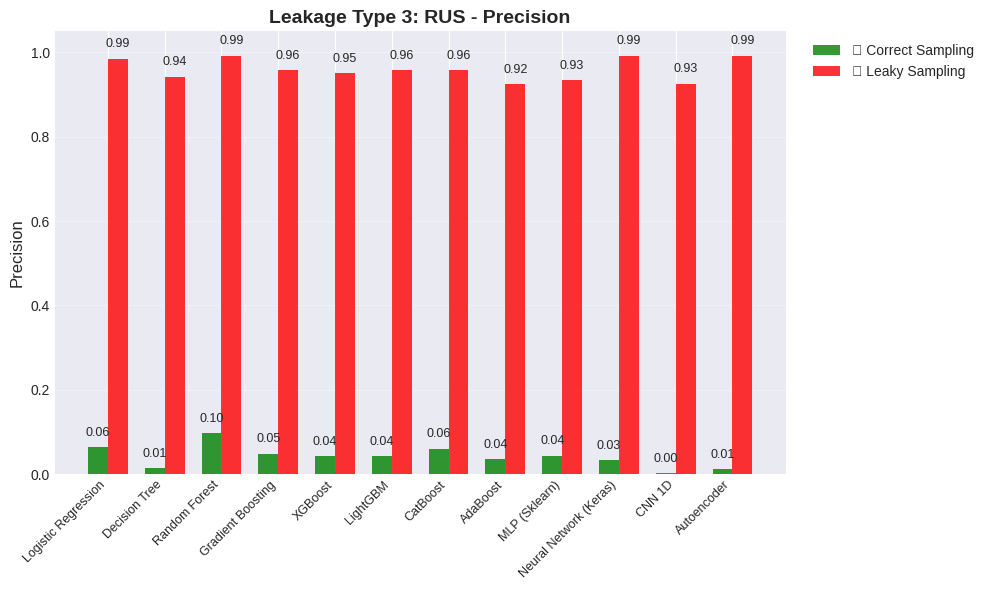

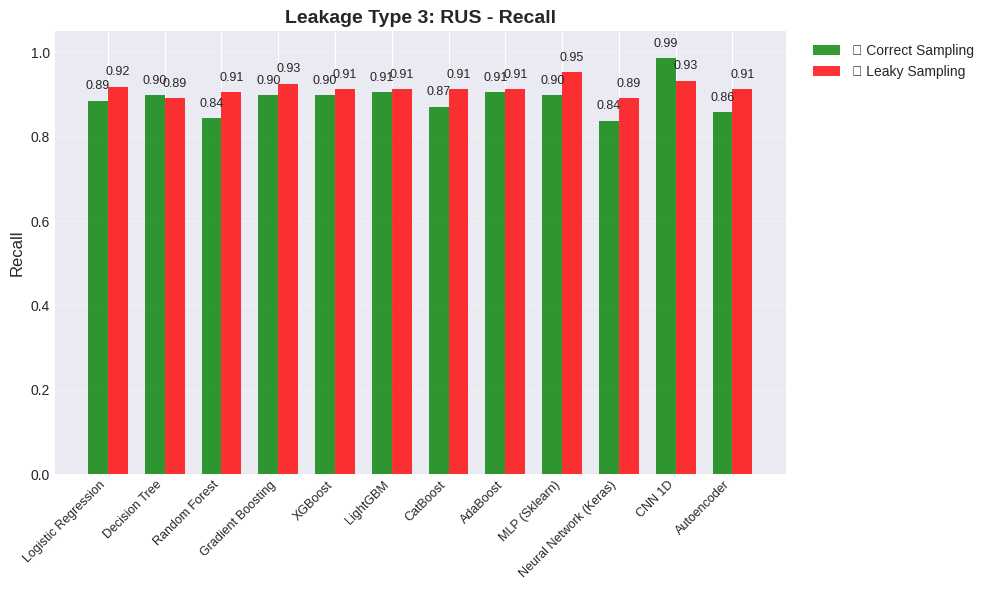

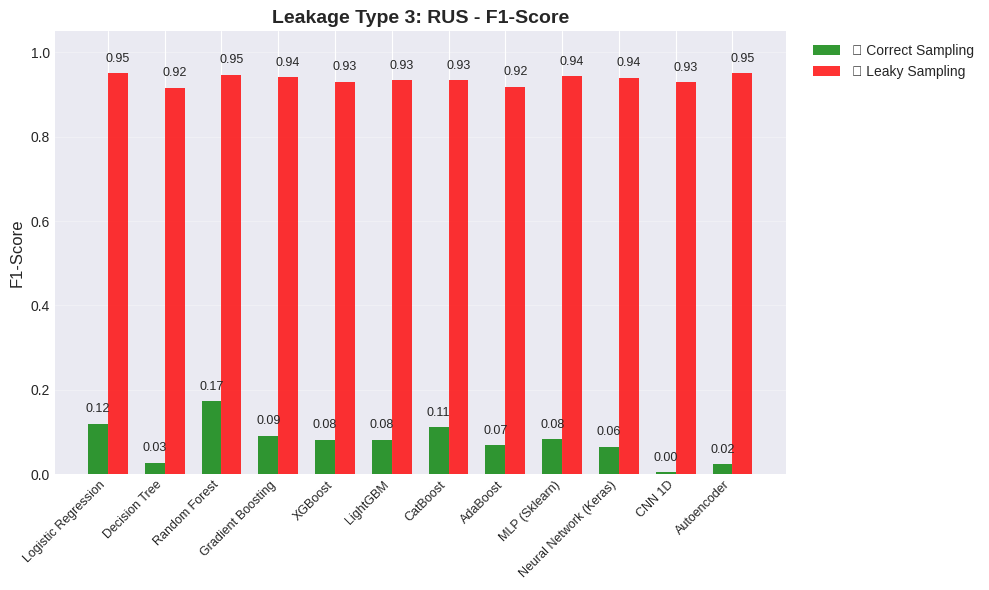

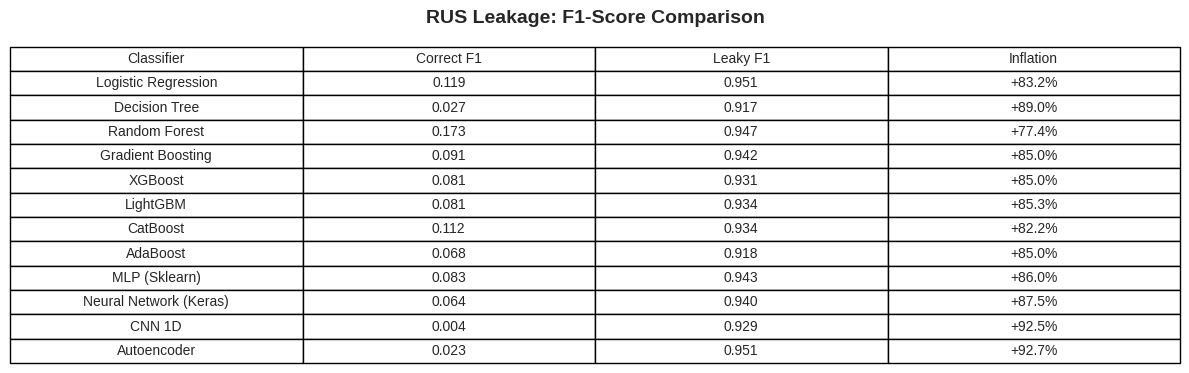

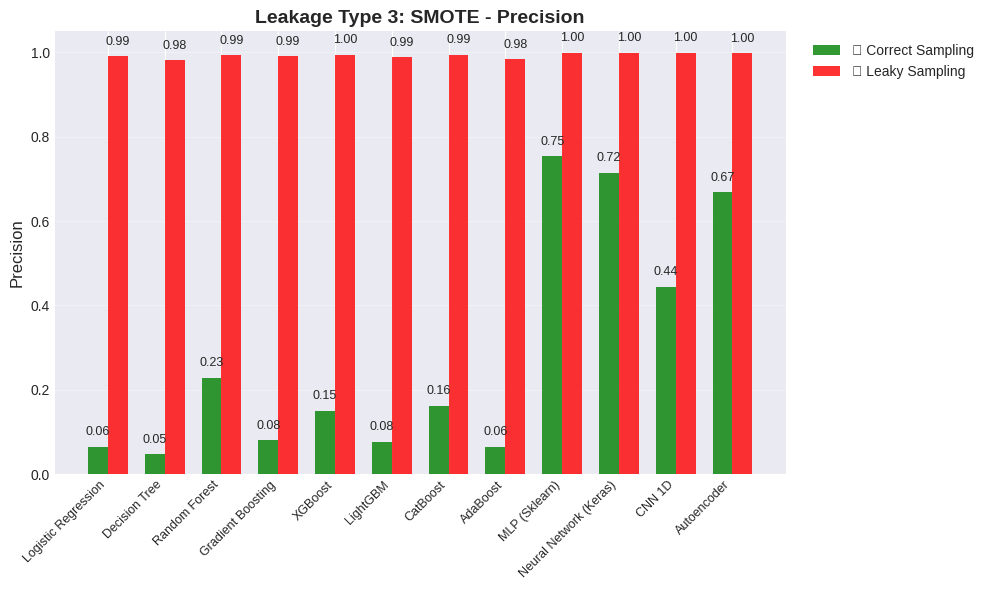

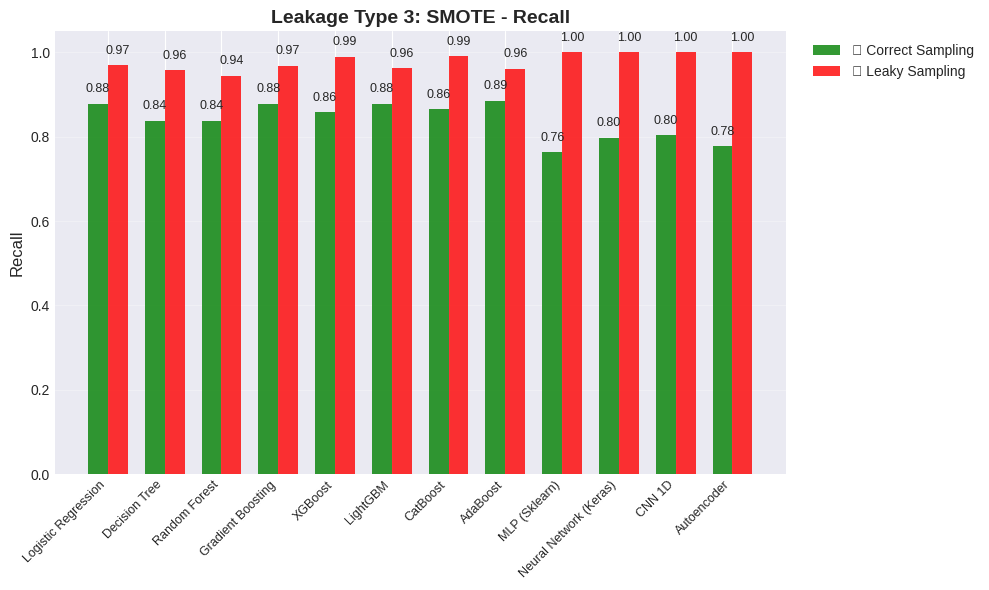

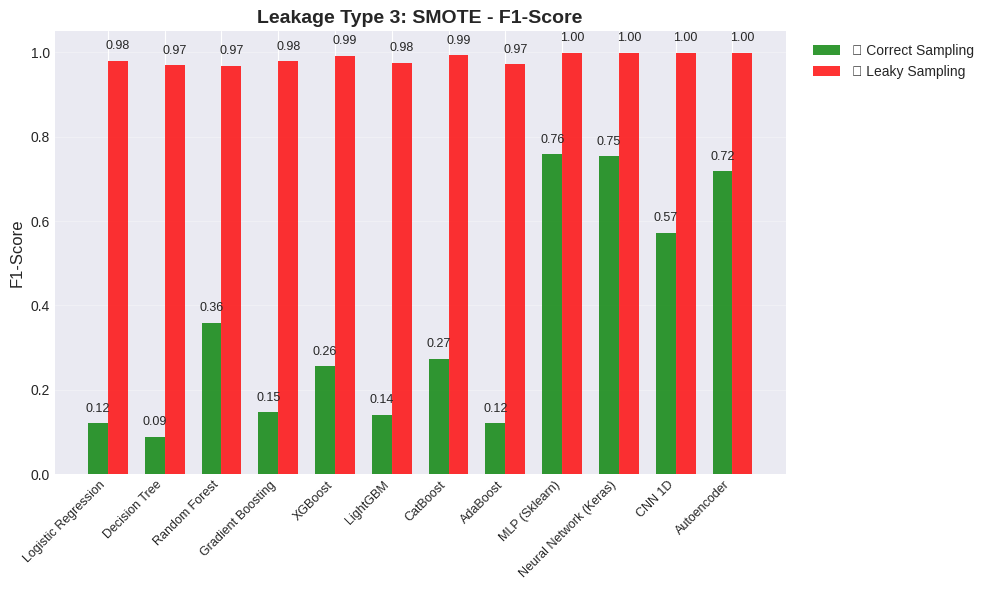

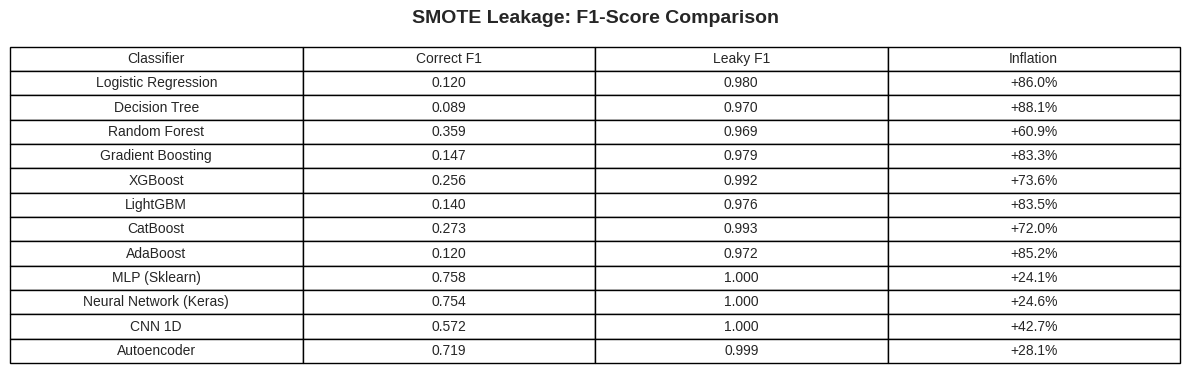

In [14]:
sampling_names = [c for c in classifiers.keys()]

# Individual graphs for Sampling Leakage (RUS and SMOTE separately)
for sampling_type, results_correct, results_leaky in [('RUS', results_rus_correct, results_rus_leaky),
                                                       ('SMOTE', results_smote_correct, results_smote_leaky)]:
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
    
    for metric in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x_pos = np.arange(len(sampling_names))
        width = 0.35
        
        correct_scores = [results_correct[name][metric] for name in sampling_names]
        leaky_scores = [results_leaky[name][metric] for name in sampling_names]
        
        bars1 = ax.bar(x_pos - width/2, correct_scores, width, label='✅ Correct Sampling', alpha=0.8, color='green')
        bars2 = ax.bar(x_pos + width/2, leaky_scores, width, label='❌ Leaky Sampling', alpha=0.8, color='red')
        
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(f'Leakage Type 3: {sampling_type} - {metric}', fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(sampling_names, rotation=45, ha='right', fontsize=9)
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 1.05])
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
    # Table for each sampling type
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    
    table_data = []
    for name in sampling_names:
        table_data.append([
            name,
            f"{results_correct[name]['F1-Score']:.3f}",
            f"{results_leaky[name]['F1-Score']:.3f}",
            f"{(results_leaky[name]['F1-Score'] - results_correct[name]['F1-Score'])*100:+.1f}%"
        ])
    
    table = ax.table(cellText=table_data,
                     colLabels=['Classifier', 'Correct F1', 'Leaky F1', 'Inflation'],
                     loc='center',
                     cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    ax.set_title(f'{sampling_type} Leakage: F1-Score Comparison', fontsize=14, fontweight='bold', pad=50)
    plt.tight_layout()
    plt.show()
    
    clear_keras_session()

### COMPLETE COMPARISON OF ALL 4 LEAKAGE TYPES

In [16]:
print("\n" + "="*80)
print("📊 COMPARING ALL FOUR LEAKAGE TYPES (F1-Score)")
print("="*80)

# Compile F1-scores for comparison
comparison_data = []
for name in [c for c in classifiers.keys() if c != 'SVM']:
    row = {
        'Classifier': name,
        'No Leakage': results_correct_scaling[name]['F1-Score'],
        'Scaling Leakage': results_leaky_scaling[name]['F1-Score'],
        'RUS Leakage': results_rus_leaky[name]['F1-Score'],
        'SMOTE Leakage': results_smote_leaky[name]['F1-Score']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Calculate the inflation caused by each leakage type
print("\n📈 PERFORMANCE INFLATION COMPARED TO NO LEAKAGE:")
for name in [c for c in classifiers.keys() if c != 'SVM']:
    print(f"\n{name}:")
    baseline = results_correct_scaling[name]['F1-Score']
    print(f"  Scaling Leakage:  +{(results_leaky_scaling[name]['F1-Score'] - baseline)*100:.1f}%")
    print(f"  RUS Leakage:      +{(results_rus_leaky[name]['F1-Score'] - baseline)*100:.1f}%")
    print(f"  SMOTE Leakage:    +{(results_smote_leaky[name]['F1-Score'] - baseline)*100:.1f}%")


📊 COMPARING ALL FOUR LEAKAGE TYPES (F1-Score)

             Classifier  No Leakage  Scaling Leakage  RUS Leakage  SMOTE Leakage
   Logistic Regression    0.713725         0.703557     0.951049       0.979954
         Decision Tree    0.822222         0.822222     0.916667       0.969787
         Random Forest    0.809160         0.809160     0.946996       0.968632
     Gradient Boosting    0.265193         0.265193     0.941581       0.979458
               XGBoost    0.798587         0.798587     0.931034       0.992495
              LightGBM    0.276498         0.392252     0.934256       0.975740
              CatBoost    0.807547         0.807547     0.934256       0.992745
              AdaBoost    0.704225         0.704225     0.918367       0.972373
         MLP (Sklearn)    0.795620         0.817518     0.943144       0.999754
Neural Network (Keras)    0.791667         0.781690     0.939502       0.999607
                CNN 1D    0.754325         0.788530     0.929293       

### Visualize All Four Leakage Types Together

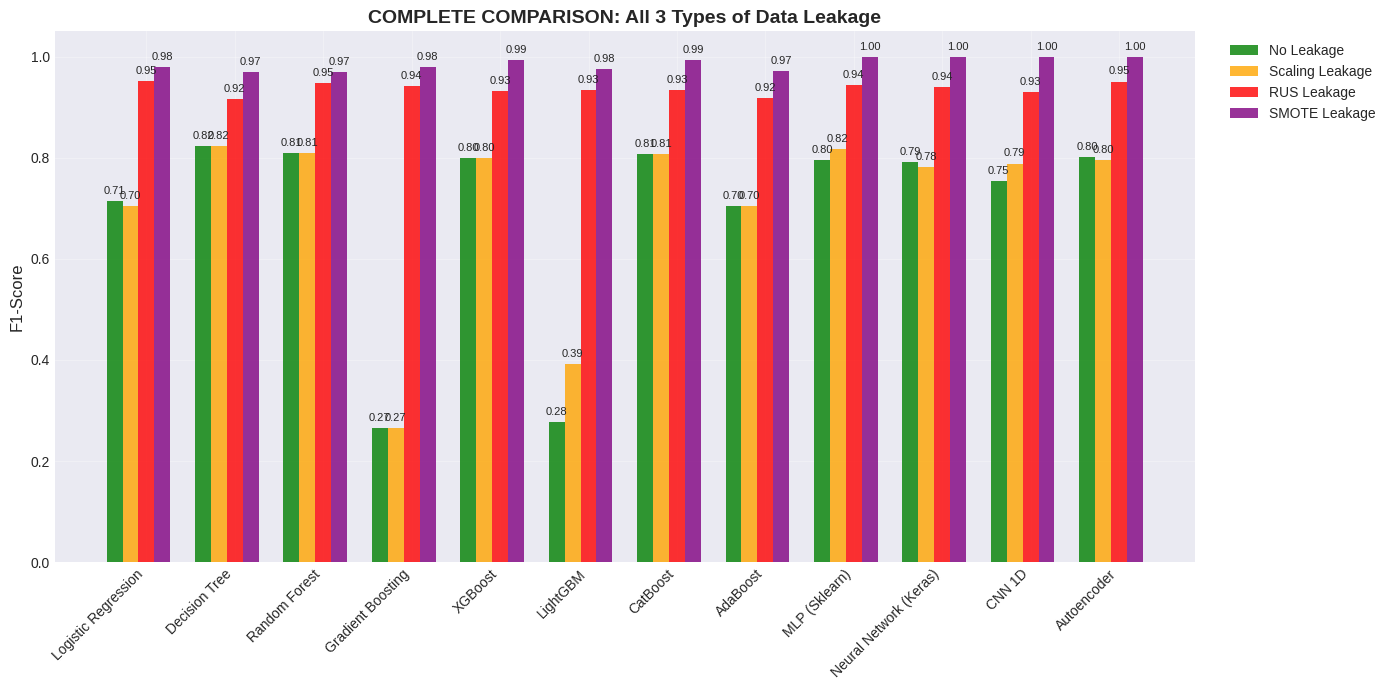

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len([c for c in classifiers.keys() if c != 'SVM']))
width = 0.18
classifier_names = [c for c in classifiers.keys() if c != 'SVM']

leakage_types = ['No Leakage', 'Scaling Leakage','RUS Leakage', 'SMOTE Leakage']
colors = ['green', 'orange', 'red', 'purple', 'brown']

for i, (leak_type, color) in enumerate(zip(leakage_types, colors)):
    offset = (i - 2) * width
    if leak_type == 'No Leakage':
        scores = [results_correct_scaling[name]['F1-Score'] for name in classifier_names]
    elif leak_type == 'Scaling Leakage':
        scores = [results_leaky_scaling[name]['F1-Score'] for name in classifier_names]
    elif leak_type == 'RUS Leakage':
        scores = [results_rus_leaky[name]['F1-Score'] for name in classifier_names]
    else:  # SMOTE Leakage
        scores = [results_smote_leaky[name]['F1-Score'] for name in classifier_names]
    
    bars = ax.bar(x_pos + offset, scores, width, label=leak_type, alpha=0.8, color=color)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        if score > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                   f'{score:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('COMPLETE COMPARISON: All 3 Types of Data Leakage', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(classifier_names, rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()
clear_keras_session()

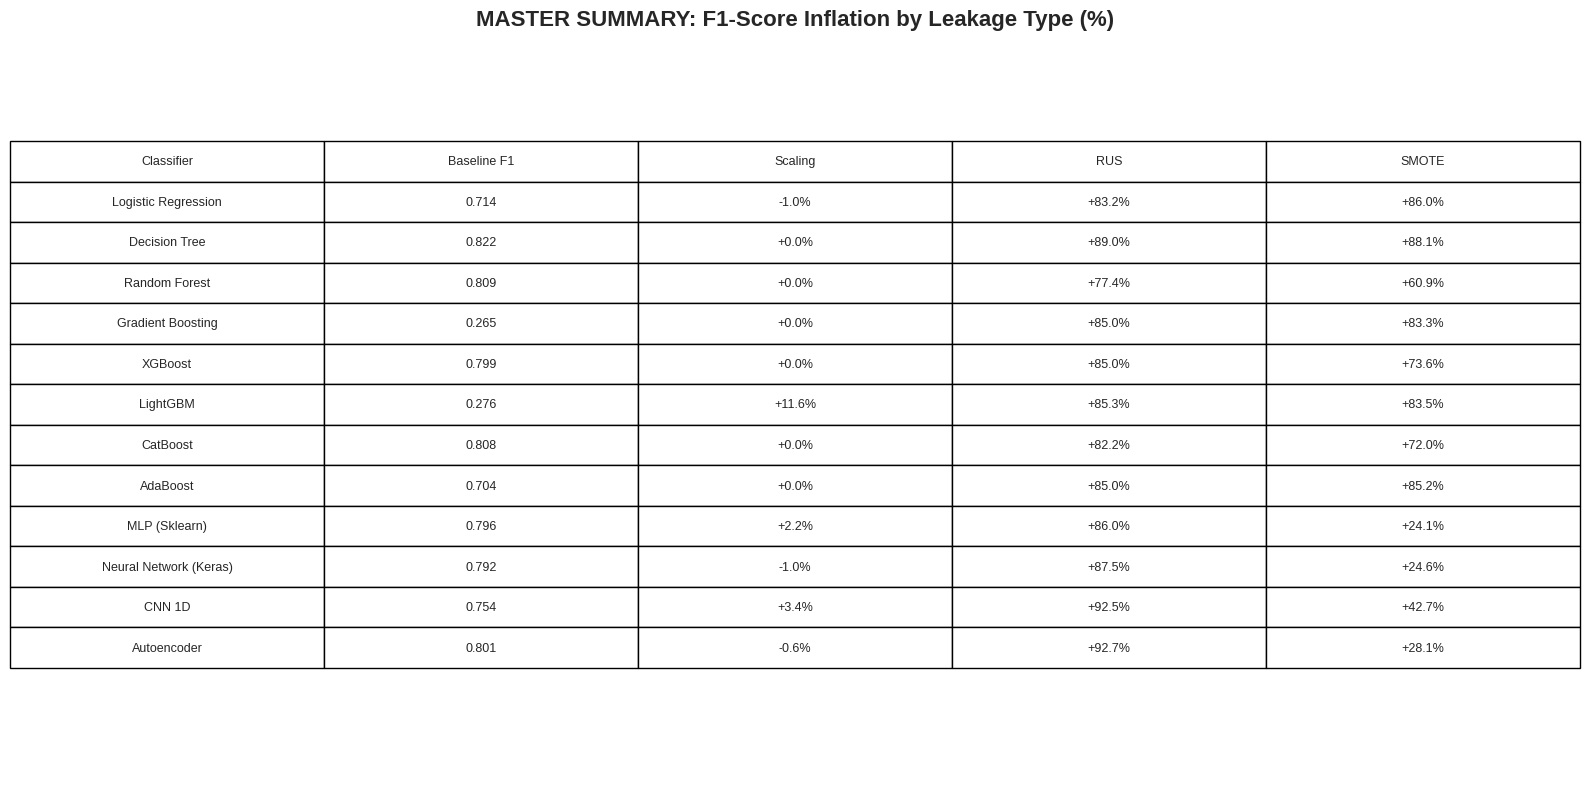

In [20]:
# Master comparison table
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

master_data = []
for name in sampling_names:
    master_data.append([
        name,
        f"{results_correct_scaling[name]['F1-Score']:.3f}",
        f"{(results_leaky_scaling[name]['F1-Score'] - results_correct_scaling[name]['F1-Score'])*100:+.1f}%",
        f"{(results_rus_leaky[name]['F1-Score'] - results_rus_correct[name]['F1-Score'])*100:+.1f}%",
        f"{(results_smote_leaky[name]['F1-Score'] - results_smote_correct[name]['F1-Score'])*100:+.1f}%"
    ])

master_table = ax.table(cellText=master_data,
                        colLabels=['Classifier', 'Baseline F1', 'Scaling', 'RUS', 'SMOTE'],
                        loc='center',
                        cellLoc='center')
master_table.auto_set_font_size(False)
master_table.set_fontsize(9)
master_table.scale(1, 2)

ax.set_title('MASTER SUMMARY: F1-Score Inflation by Leakage Type (%)', fontsize=16, fontweight='bold', pad=0)
plt.tight_layout()
plt.show()